## Imports

In [1]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots

In [2]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence \
import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

In [3]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
summarize ,
poly)

### LOAD Data

In [4]:
auto = load_data("auto")
bike = load_data("bikeshare")
Boston = load_data("Boston")
brain = load_data("braincancer")
caravan = load_data("caravan")
Carseats = load_data("carseats")
college = load_data("college")
credit= load_data("credit")
default = load_data("default")
fund = load_data("fund")
hitters = load_data("Hitters")
kxtest = load_data("khan_xtest")
kytest = load_data("khan_ytest")
kxtrain = load_data("khan_xtrain")
kytrain = load_data("khan_ytrain")
nci = load_data("NCI60labs")
nyse = load_data("nyse")
oj = load_data("OJ")
portfolio = load_data("portfolio")
pubs = load_data("publication")
wage = load_data("wage")
weekly = load_data("weekly")
Smarket = load_data("smarket")


## Chapter 3

### Functions

#### DIR()

In [5]:
A = np.array([3,5,11])
dir(A)

['T',
 '__abs__',
 '__add__',
 '__and__',
 '__array__',
 '__array_finalize__',
 '__array_function__',
 '__array_interface__',
 '__array_namespace__',
 '__array_priority__',
 '__array_struct__',
 '__array_ufunc__',
 '__array_wrap__',
 '__bool__',
 '__buffer__',
 '__class__',
 '__class_getitem__',
 '__complex__',
 '__contains__',
 '__copy__',
 '__deepcopy__',
 '__delattr__',
 '__delitem__',
 '__dir__',
 '__divmod__',
 '__dlpack__',
 '__dlpack_device__',
 '__doc__',
 '__eq__',
 '__float__',
 '__floordiv__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__iadd__',
 '__iand__',
 '__ifloordiv__',
 '__ilshift__',
 '__imatmul__',
 '__imod__',
 '__imul__',
 '__index__',
 '__init__',
 '__init_subclass__',
 '__int__',
 '__invert__',
 '__ior__',
 '__ipow__',
 '__irshift__',
 '__isub__',
 '__iter__',
 '__itruediv__',
 '__ixor__',
 '__le__',
 '__len__',
 '__lshift__',
 '__lt__',
 '__matmul__',
 '__mod__',
 '__mul__',
 '__ne__',
 '__neg__',


#### Sum()

In [6]:
A.sum()

np.int64(19)

### Boston dataset

In [7]:

Boston.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat', 'medv'],
      dtype='str')

In [8]:
X = pd.DataFrame({'intercept': np.ones(Boston.shape[0]),
'lstat': Boston['lstat']})
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


In [9]:
y = Boston['medv']
model = sm.OLS(y, X)
results = model.fit()

### Summarize

In [10]:
summarize(results)

,coef,std err,t,P>|t|
intercept,34.5538,0.563,61.415,0.0
lstat,-0.9500,0.039,-24.528,0.0


In [11]:
design = MS(['lstat'])
design = design.fit(Boston)
X = design.transform(Boston)
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


In [12]:
design = MS(['lstat'])
X = design.fit_transform(Boston)
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


In [13]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Thu, 27 Aug 2026   Prob (F-statistic):           5.08e-88
Time:                        12:39:59   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     34.5538      0.563     61.415      0.000      33.448      35.659
lstat         -0.9500      0.039    -24.528      0.000      -1.026      -0.874
==============================================================================
Omnibus:                      137.043   Durbin-Watson:                   0.892
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              291.373
Skew:                           1.453   Prob(JB):                     5.36e-64
Kurtosis:                       5.319   Cond. No.                         29.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Params

In [14]:
results.params

intercept    34.553841
lstat        -0.950049
dtype: float64

In [15]:
new_df = pd.DataFrame({'lstat':[5, 10, 15]})
newX = design.transform(new_df)
newX

,intercept,lstat
0,1.0,5
1,1.0,10
2,1.0,15


### Predictions

In [16]:
new_predictions = results.get_prediction(newX);
new_predictions.predicted_mean

array([29.80359411, 25.05334734, 20.30310057])

In [17]:
new_predictions.conf_int(alpha=0.05)

array([[29.00741194, 30.59977628],
       [24.47413202, 25.63256267],
       [19.73158815, 20.87461299]])

In [18]:
new_predictions.conf_int(obs=True , alpha=0.05)

array([[17.56567478, 42.04151344],
       [12.82762635, 37.27906833],
       [ 8.0777421 , 32.52845905]])

### abline function

In [19]:
def abline(ax, b, m):
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim , ylim)

In [20]:
def abline(ax, b, m, *args , **kwargs):
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim , ylim , *args , **kwargs)

ax = Boston.plot.scatter('lstat', 'medv')
abline(ax, 
       results.params[0], 
       results.params[1], 
       'r--', 
       linewidth=3)

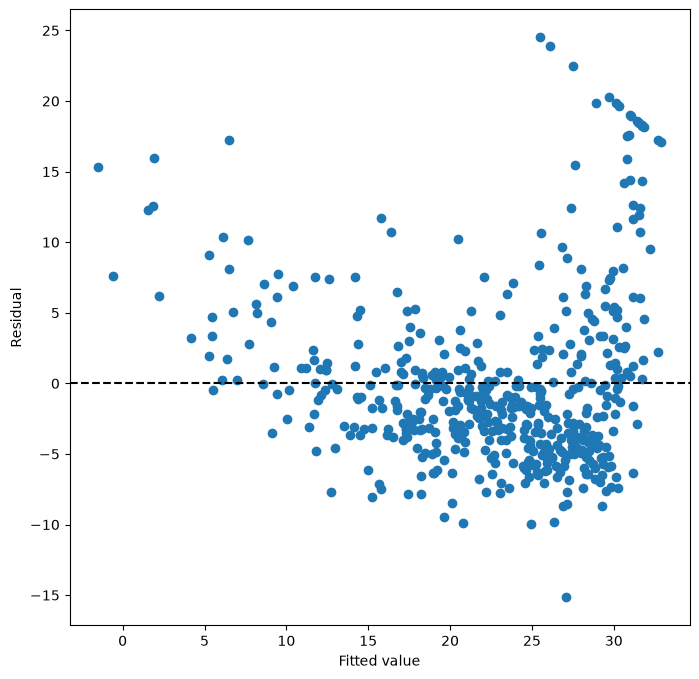

In [21]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(results.fittedvalues , results.resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');

np.int64(374)

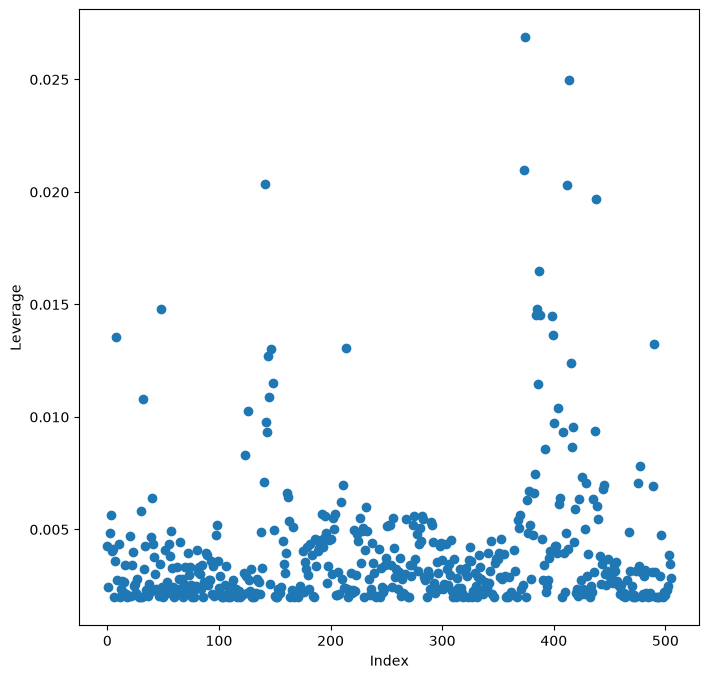

In [22]:
infl = results.get_influence()
ax = subplots(figsize=(8,8))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)

In [23]:
X = MS(['lstat', 'age']).fit_transform(Boston)
model1 = sm.OLS(y, X)
results1 = model1.fit()
summarize(results1)

,coef,std err,t,P>|t|
intercept,33.2228,0.731,45.458,0.000
lstat,-1.0321,0.048,-21.416,0.000
age,0.0345,0.012,2.826,0.005


In [24]:
terms = Boston.columns.drop('medv')
terms

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat'],
      dtype='str')

In [25]:
X = MS(terms).fit_transform(Boston)
model = sm.OLS(y, X)
results = model.fit()
summarize(results)

,coef,std err,t,P>|t|
intercept,41.6173,4.936,8.431,0.000
crim,-0.1214,0.033,-3.678,0.000
zn,0.0470,0.014,3.384,0.001
indus,0.0135,0.062,0.217,0.829
chas,2.8400,0.870,3.264,0.001
nox,-18.7580,3.851,-4.870,0.000
rm,3.6581,0.420,8.705,0.000
age,0.0036,0.013,0.271,0.787
dis,-1.4908,0.202,-7.394,0.000
rad,0.2894,0.067,4.325,0.000


What if we would like to perform a regression using all of the variables but
one? For example, in the above regression output, age has a high p-value.
So we may wish to run a regression excluding this predictor. The following
syntax results in a regression using all predictors except age (output not
shown).

In [26]:
minus_age = Boston.columns.drop(['medv', 'age'])
Xma = MS(minus_age).fit_transform(Boston)
model1 = sm.OLS(y, Xma)
summarize(model1.fit())

,coef,std err,t,P>|t|
intercept,41.5251,4.920,8.441,0.000
crim,-0.1214,0.033,-3.683,0.000
zn,0.0465,0.014,3.379,0.001
indus,0.0135,0.062,0.217,0.829
chas,2.8528,0.868,3.287,0.001
nox,-18.4851,3.714,-4.978,0.000
rm,3.6811,0.411,8.951,0.000
dis,-1.5068,0.193,-7.825,0.000
rad,0.2879,0.067,4.322,0.000
tax,-0.0127,0.004,-3.333,0.001


List comprehensions are simple and powerful ways to form lists of Python
objects. The language also supports dictionary and generator comprehension,
though these are beyond our scope here. Let’s look at an example.
We compute the VIF for each of the variables in the model matrix X, using
the function variance_inflation_factor().

In [27]:
vals = [VIF(X, i)
for i in range(1, X.shape[1])]
vif = pd.DataFrame({'vif':vals},
index=X.columns [1:])
vif

,vif
crim,1.767486
zn,2.298459
indus,3.987181
chas,1.071168
nox,4.369093
rm,1.912532
age,3.088232
dis,3.954037
rad,7.445301
tax,9.002158


The function VIF() takes two arguments: a dataframe or array, and a variable
column index. In the code above we call VIF() on the fly for all columns
in X. We have excluded column 0 above (the intercept), which is not of interest.
In this case the VIFs are not that exciting.
The object vals above could have been constructed with the following
for loop:

In [28]:
vals = []
for i in range(1, X.values.shape[1]):
    vals.append(VIF(X.values , i))

### ModelSpec as MS

It is easy to include interaction terms in a linear model using ModelSpec().
Including a tuple ("lstat","age") tells the model matrix builder to include
an interaction term between lstat and age.

In [29]:
X = MS(['lstat',
'age',
('lstat', 'age')]).fit_transform(Boston)
model2 = sm.OLS(y, X)
summarize(model2.fit())

,coef,std err,t,P>|t|
intercept,36.0885,1.470,24.553,0.000
lstat,-1.3921,0.167,-8.313,0.000
age,-0.0007,0.020,-0.036,0.971
lstat:age,0.0042,0.002,2.244,0.025


### Poly function

The model matrix builder can include terms beyond just column names and
interactions. For instance, the poly() function supplied in ISLP specifies that columns representing polynomial functions of its first argument are
added to the model matrix.

In [30]:
X = MS([poly('lstat', degree=2), 'age']).fit_transform(Boston)
model3 = sm.OLS(y, X)
results3 = model3.fit()
summarize(results3)

,coef,std err,t,P>|t|
intercept,17.7151,0.781,22.681,0.0
"poly(lstat, degree=2)[0]",-179.2279,6.733,-26.620,0.0
"poly(lstat, degree=2)[1]",72.9908,5.482,13.315,0.0
age,0.0703,0.011,6.471,0.0


In [31]:
anova_lm(results1 , results3)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,503.0,19168.128609,0.0,NaN,NaN,NaN
1,502.0,14165.613251,1.0,5002.515357,177.278785,7.468491e-35


We see that when the quadratic term is included in the model, there is
little discernible pattern in the residuals. In order to create a cubic or
higher-degree polynomial fit, we can simply change the degree argument to
poly().

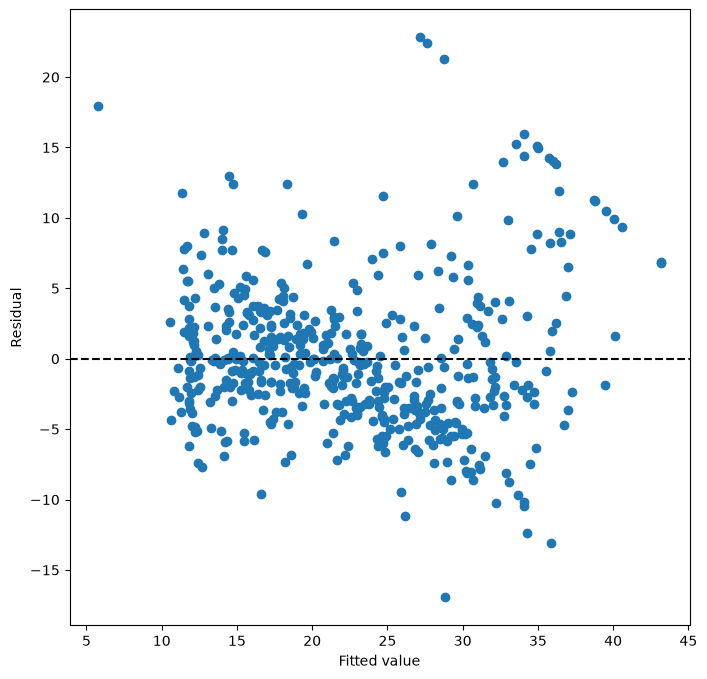

In [32]:
ax = subplots(figsize=(8,8))[1]
ax.scatter(results3.fittedvalues , results3.resid)
ax.set_xlabel('Fitted value')
ax.set_ylabel('Residual')
ax.axhline(0, c='k', ls='--');

### Carseats dataset

In [33]:
Carseats.columns

Index(['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
      dtype='str')

In [34]:
allvars = list(Carseats.columns.drop('Sales'))
y = Carseats['Sales']
final = allvars + [('Income', 'Advertising'),
('Price', 'Age')]
X = MS(final).fit_transform(Carseats)
# model = sm.OLS(y, X)
# summarize(model.fit())

## Chapter 4 Lab

In [35]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
summarize)

In [36]:
from ISLP import confusion_table
from ISLP.models import contrast
from sklearn.discriminant_analysis import \
(LinearDiscriminantAnalysis as LDA ,
QuadraticDiscriminantAnalysis as QDA)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

### Smarket dataset

In [37]:
Smarket

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,2001,0.381,-0.192,-2.624,-1.055,5.010,1.19130,0.959,Up
1,2001,0.959,0.381,-0.192,-2.624,-1.055,1.29650,1.032,Up
2,2001,1.032,0.959,0.381,-0.192,-2.624,1.41120,-0.623,Down
3,2001,-0.623,1.032,0.959,0.381,-0.192,1.27600,0.614,Up
4,2001,0.614,-0.623,1.032,0.959,0.381,1.20570,0.213,Up
...,...,...,...,...,...,...,...,...,...
1245,2005,0.422,0.252,-0.024,-0.584,-0.285,1.88850,0.043,Up
1246,2005,0.043,0.422,0.252,-0.024,-0.584,1.28581,-0.955,Down
1247,2005,-0.955,0.043,0.422,0.252,-0.024,1.54047,0.130,Up
1248,2005,0.130,-0.955,0.043,0.422,0.252,1.42236,-0.298,Down


In [38]:
Smarket.columns


Index(['Year', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today',
       'Direction'],
      dtype='str')

Smarket.corr()

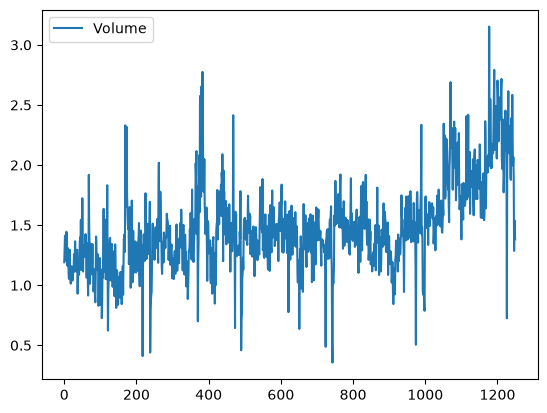

In [39]:
Smarket.plot(y='Volume');

### 4.7.2 Logistic Regression

Next, we will fit a logistic regression model in order to predict Direction
using Lag1 through Lag5 and Volume. The sm.GLM() function fits gener- alized linear models, a class of models that includes logistic regression. sm.GLM() generalized
Alternatively, the function sm.Logit() fits a logistic regression model di- linear model
rectly. The syntax of sm.GLM() is similar to that of sm.OLS(), except that
we must pass in the argument family=sm.families.Binomial() in order to
tell statsmodels to run a logistic regression rather than some other type of
generalized linear model.

In [40]:
allvars = Smarket.columns.drop(['Today', 'Direction', 'Year'])
design = MS(allvars)
X = design.fit_transform(Smarket)
y = Smarket.Direction == 'Up'
glm = sm.GLM(y,
X,
family=sm.families.Binomial())
results = glm.fit()
summarize(results)

,coef,std err,z,P>|z|
intercept,-0.1260,0.241,-0.523,0.601
Lag1,-0.0731,0.050,-1.457,0.145
Lag2,-0.0423,0.050,-0.845,0.398
Lag3,0.0111,0.050,0.222,0.824
Lag4,0.0094,0.050,0.187,0.851
Lag5,0.0103,0.050,0.208,0.835
Volume,0.1354,0.158,0.855,0.392


The smallest p-value here is associated with Lag1. The negative coefficient
for this predictor suggests that if the market had a positive return yesterday,
then it is less likely to go up today. However, at a value of 0.15, the p-value
is still relatively large, and so there is no clear evidence of a real association
between Lag1 and Direction.
We use the params attribute of results in order to access just the coefficients
for this fitted model.

In [41]:
results.params

intercept   -0.126000
Lag1        -0.073074
Lag2        -0.042301
Lag3         0.011085
Lag4         0.009359
Lag5         0.010313
Volume       0.135441
dtype: float64

Likewise we can use the pvalues attribute to access the p-values for the
coefficients.

In [42]:
results.pvalues

intercept    0.600700
Lag1         0.145232
Lag2         0.398352
Lag3         0.824334
Lag4         0.851445
Lag5         0.834998
Volume       0.392404
dtype: float64

The predict() method of results can be used to predict the probability
that the market will go up, given values of the predictors. This method
returns predictions on the probability scale. If no data set is supplied to
the predict() function, then the probabilities are computed for the training
data that was used to fit the logistic regression model. As with linear
regression, one can pass an optional exog argument consistent with a design
matrix if desired. Here we have printed only the first twenty probabilities.

In [43]:
probs = results.predict()
probs[:20]

array([0.50708413, 0.48146788, 0.48113883, 0.51522236, 0.51078116,
       0.50695646, 0.49265087, 0.50922916, 0.51761353, 0.48883778,
       0.4965211 , 0.51978335, 0.51830311, 0.49638523, 0.48648924,
       0.515366  , 0.50539764, 0.53193216, 0.51671635, 0.49832725])

In order to make a prediction as to whether the market will go up or
down on a particular day, we must convert these predicted probabilities
into class labels, Up or Down. The following two commands create a vector
of class predictions based on whether the predicted probability of a market
increase is greater than or less than 0.5.

In [44]:
labels = np.array(['Down']*1250)
labels[probs >0.5] = "Up"

### Confusion_table() function

The confusion_table() function from the ISLP package summarizes these 
predictions, showing how many observations were correctly or incorrectly 
classified. Our function, which is adapted from a similar function in the
module sklearn.metrics, transposes the resulting matrix and includes row
and column labels. The confusion_table() function takes as first argument
the predicted labels, and second argument the true labels.

In [45]:
confusion_table(labels , Smarket.Direction)

Truth,Down,Up
Predicted,,
Down,145,141
Up,457,507


The diagonal elements of the confusion matrix indicate correct predictions,
while the off-diagonals represent incorrect predictions. Hence our model
correctly predicted that the market would go up on 507 days and that
it would go down on 145 days, for a total of 507 + 145 = 652 correct
predictions. The np.mean() function can be used to compute the fraction of
days for which the prediction was correct. In this case, logistic regression
correctly predicted the movement of the market 52.2% of the time.

In [46]:
(507+145)/1250, np.mean(labels == Smarket.Direction)

(0.5216, np.float64(0.5216))

At first glance, it appears that the logistic regression model is working
a little better than random guessing. However, this result is misleading
because we trained and tested the model on the same set of 1,250 observations.
In other words, 100 − 52.2 = 47.8% is the training error rate. As
we have seen previously, the training error rate is often overly optimistic
— it tends to underestimate the test error rate. In order to better assess
the accuracy of the logistic regression model in this setting, we can fit the
model using part of the data, and then examine how well it predicts the
held out data. This will yield a more realistic error rate, in the sense that in
practice we will be interested in our model’s performance not on the data
that we used to fit the model, but rather on days in the future for which
the market’s movements are unknown.
To implement this strategy, we first create a Boolean vector corresponding
to the observations from 2001 through 2004. We then use this vector
to create a held out data set of observations from 2005.

#### using tilde(~) as not

In [47]:
train = (Smarket.Year < 2005)
Smarket_train = Smarket.loc[train]
Smarket_test = Smarket.loc[~train]
Smarket_test.shape

(252, 9)

#### Separate train and test data

The object train is a vector of 1,250 elements, corresponding to the
observations in our data set. The elements of the vector that correspond
to observations that occurred before 2005 are set to True, whereas those
that correspond to observations in 2005 are set to False. Hence train is a
boolean array, since its elements are True and False. Boolean arrays can be
used to obtain a subset of the rows or columns of a data frame using the loc method. For instance, the command Smarket.loc[train] would pick
out a submatrix of the stock market data set, corresponding only to the
dates before 2005, since those are the ones for which the elements of train
are True. The # symbol can be used to negate all of the elements of a
Boolean vector. That is, #train is a vector similar to train, except that
the elements that are True in train get swapped to False in #train, and
vice versa. Therefore, Smarket.loc[#train] yields a subset of the rows of
the data frame of the stock market data containing only the observations
for which train is False. The output above indicates that there are 252
such observations.
We now fit a logistic regression model using only the subset of the observations
that correspond to dates before 2005. We then obtain predicted
probabilities of the stock market going up for each of the days in our test
set — that is, for the days in 2005.

In [48]:
X_train , X_test = X.loc[train], X.loc[~train]
y_train , y_test = y.loc[train], y.loc[~train]
glm_train = sm.GLM(y_train ,
X_train ,
family=sm.families.Binomial())
results = glm_train.fit()
probs = results.predict(exog=X_test)

Notice that we have trained and tested our model on two completely
separate data sets: training was performed using only the dates before
2005, and testing was performed using only the dates in 2005.
Finally, we compare the predictions for 2005 to the actual movements of
the market over that time period. We will first store the test and training
labels (recall y_test is binary).

In [49]:
D = Smarket.Direction
L_train , L_test = D.loc[train], D.loc[~train]

Now we threshold the fitted probability at 50% to form our predicted labels.

In [50]:
labels = np.array(['Down']*252)
labels[probs >0.5] = 'Up'
confusion_table(labels , L_test)

Truth,Down,Up
Predicted,,
Down,77,97
Up,34,44


The test accuracy is about 48% while the error rate is about 52%

In [51]:
np.mean(labels == L_test), np.mean(labels != L_test)

(np.float64(0.4801587301587302), np.float64(0.5198412698412699))